# VGG MODEL

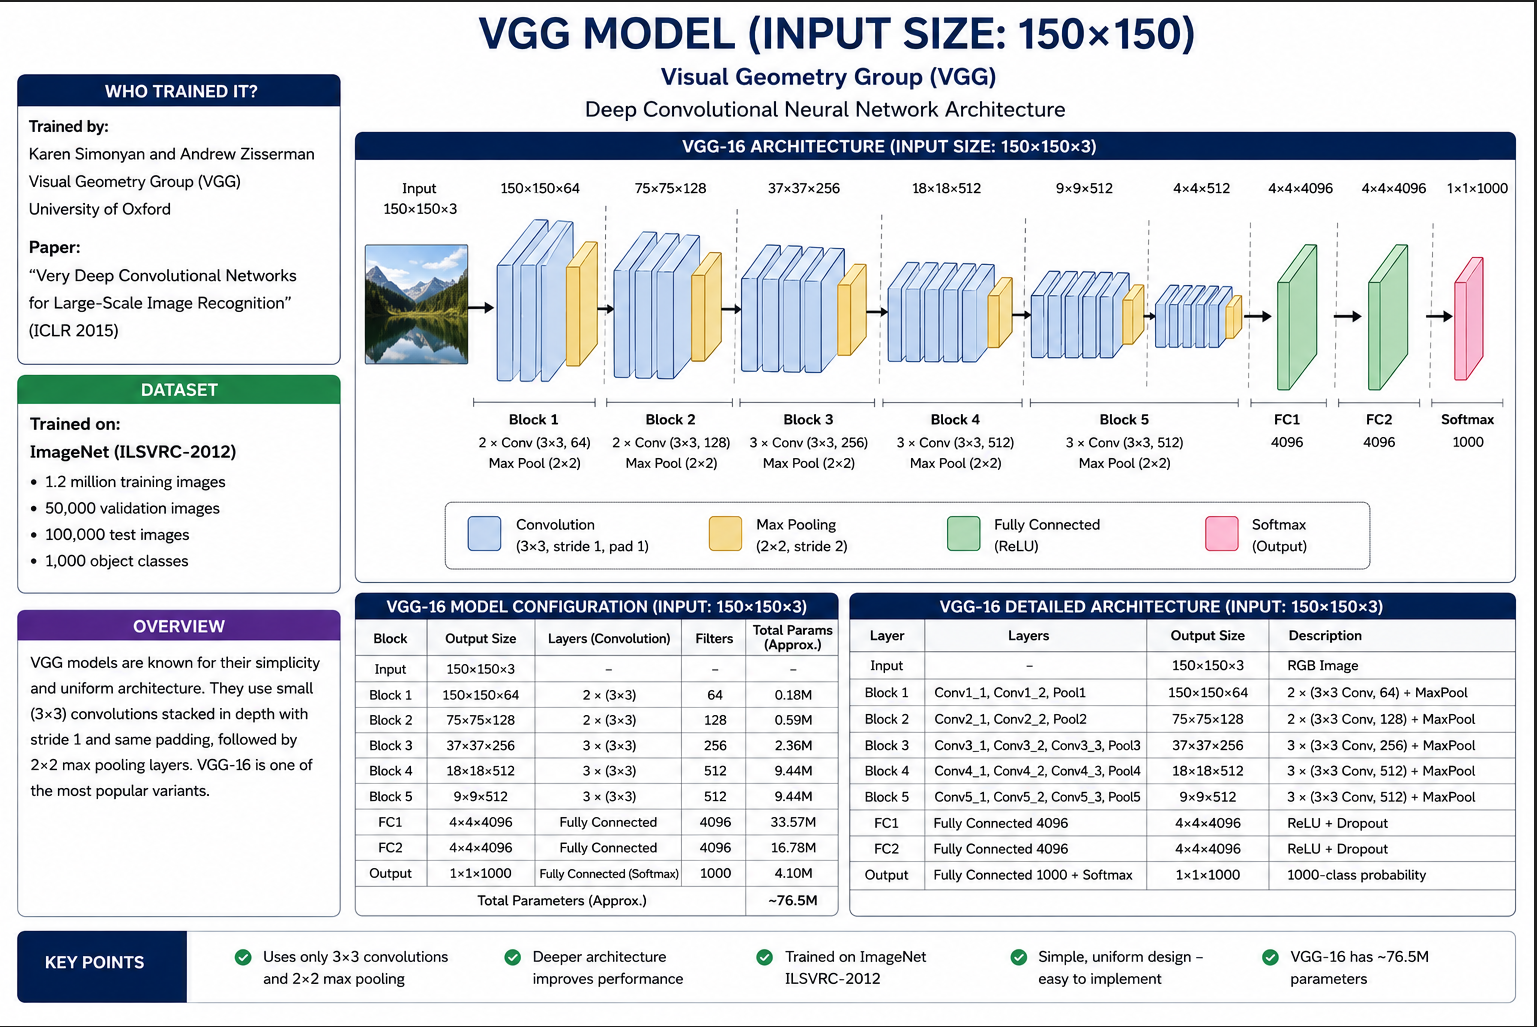

## Dataset Link
[https://www.kaggle.com/datasets/vishesh1412/celebrity-face-image-dataset](http://)

## Visualizing the Dataset

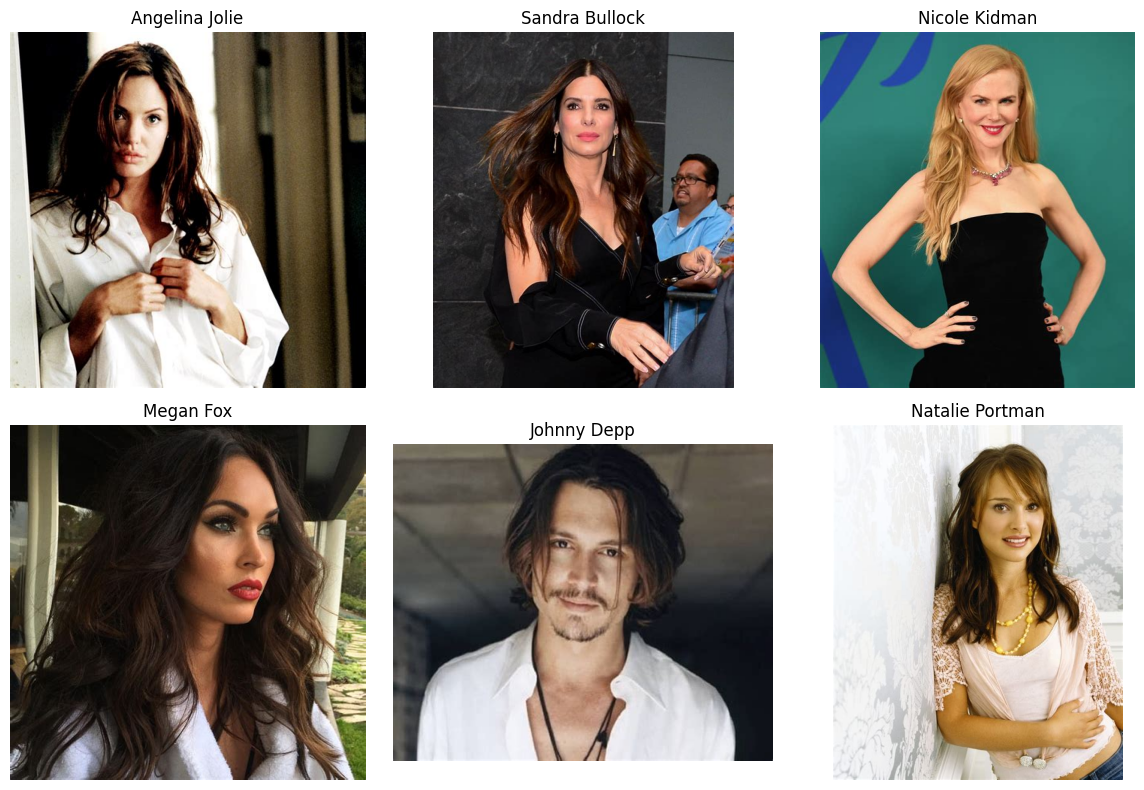

In [36]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

base_path = "/kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset"

# First 6 celebrity folders
first_6_images = [
    os.path.join(base_path, folder)
    for folder in os.listdir(base_path)[:6]
]

# Load the first image from each folder
images = []
labels = []

for folder in first_6_images:
    first_image = os.listdir(folder)[0]
    img_path = os.path.join(folder, first_image)

    images.append(np.array(Image.open(img_path)))
    labels.append(os.path.basename(folder))

# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, img, label in zip(axes.flatten(), images, labels):
    ax.imshow(img)
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()
plt.show()

## See the Target Distribution

In [37]:
labels = sorted(os.listdir(base_path))
print(labels)
print("Category Count :", len(labels))

['Angelina Jolie', 'Brad Pitt', 'Denzel Washington', 'Hugh Jackman', 'Jennifer Lawrence', 'Johnny Depp', 'Kate Winslet', 'Leonardo DiCaprio', 'Megan Fox', 'Natalie Portman', 'Nicole Kidman', 'Robert Downey Jr', 'Sandra Bullock', 'Scarlett Johansson', 'Tom Cruise', 'Tom Hanks', 'Will Smith']
Category Count : 17


## Check Image Count Inside Each Category

Angelina Jolie: 100
Brad Pitt: 100
Denzel Washington: 100
Hugh Jackman: 100
Jennifer Lawrence: 100
Johnny Depp: 100
Kate Winslet: 100
Leonardo DiCaprio: 100
Megan Fox: 100
Natalie Portman: 100
Nicole Kidman: 100
Robert Downey Jr: 100
Sandra Bullock: 100
Scarlett Johansson: 200
Tom Cruise: 100
Tom Hanks: 100
Will Smith: 100


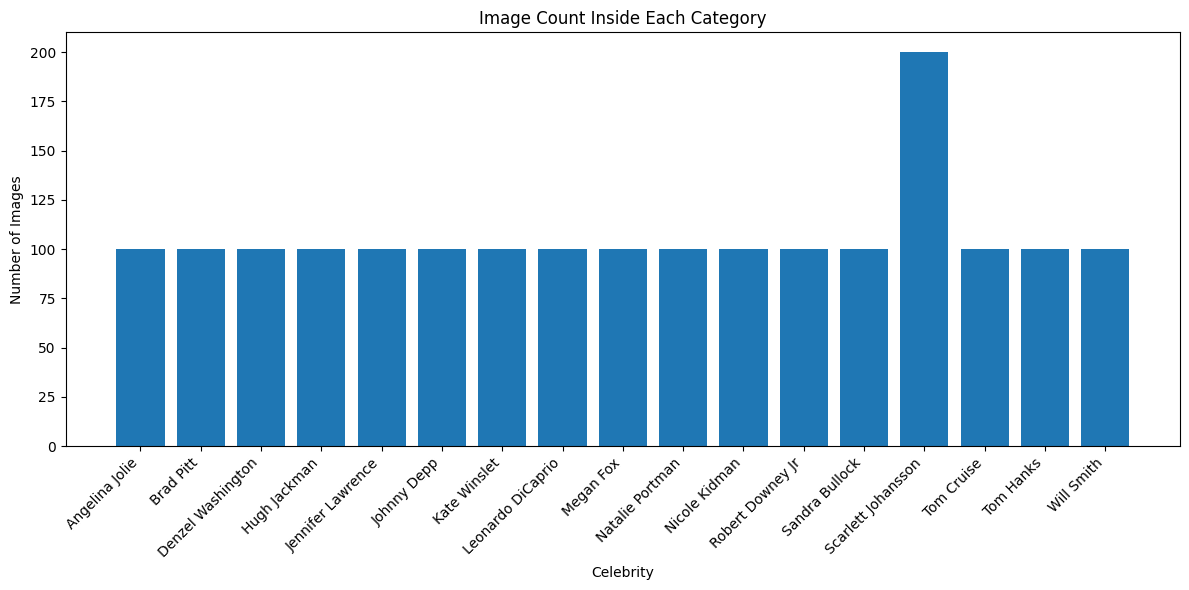

In [40]:
import os
import matplotlib.pyplot as plt

base_path = "/kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset"

labels = []
counts = []

for category in sorted(os.listdir(base_path)):
    category_path = os.path.join(base_path, category)

    if os.path.isdir(category_path):
        labels.append(category)
        count = len(os.listdir(category_path))
        counts.append(count)
        print(f"{category}: {count}")

plt.figure(figsize=(12, 6))
plt.bar(labels, counts)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Celebrity")
plt.ylabel("Number of Images")
plt.title("Image Count Inside Each Category")
plt.tight_layout()
plt.show()

In [41]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Flatten
from keras.applications.vgg16 import VGG16

In [42]:
# conv_base = VGG16(
#     weights='imagenet',
#     include_top = False, # do not include the final classification layers of the pretrained model.
#     input_shape=(150,150,3)
# )

conv_base = VGG16(
    weights=f"/kaggle/input/models/mirajverisk/vgg/tensorflow2/default/1/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5",
    include_top=False,
    input_shape=(150, 150, 3)
)

In [43]:
model = Sequential()
model.add(conv_base)
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(17,activation='softmax'))

In [44]:
for layer in conv_base.layers:
    print(layer.name, layer.trainable)

input_layer_4 True
block1_conv1 True
block1_conv2 True
block1_pool True
block2_conv1 True
block2_conv2 True
block2_pool True
block3_conv1 True
block3_conv2 True
block3_conv3 True
block3_pool True
block4_conv1 True
block4_conv2 True
block4_conv3 True
block4_pool True
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True


In [45]:
# Unfreeze the convolutional base
conv_base.trainable = True

# Freeze all layers first
for layer in conv_base.layers:
    layer.trainable = False

# Unfreeze only Block 5
for layer in conv_base.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True

## Split Dataset into Train / Test Directories

### Format Dataset Like This

```text
celeb_faces/
├── Train/
│   ├── Angelina Jolie/
│   ├── Brad Pitt/
│   ├── Denzel Washington/
│   └── ...
└── Test/
    ├── Angelina Jolie/
    ├── Brad Pitt/
    ├── Denzel Washington/
    └── ...
```

In [46]:
import os
import shutil
from sklearn.model_selection import train_test_split

base_path = "/kaggle/input/datasets/vishesh1412/celebrity-face-image-dataset/Celebrity Faces Dataset"

# New dataset location
output_root = "celeb_faces"
train_path = os.path.join(output_root, "Train")
test_path = os.path.join(output_root, "Test")

# Remove old split if it exists
if os.path.exists(output_root):
    shutil.rmtree(output_root)

os.makedirs(train_path)
os.makedirs(test_path)

for category in sorted(os.listdir(base_path)):
    category_path = os.path.join(base_path, category)

    if not os.path.isdir(category_path):
        continue

    images = [
        os.path.join(category_path, img)
        for img in os.listdir(category_path)
    ]

    train_imgs, test_imgs = train_test_split(
        images,
        test_size=0.2,
        random_state=42
    )

    train_class = os.path.join(train_path, category)
    test_class = os.path.join(test_path, category)

    os.makedirs(train_class, exist_ok=True)
    os.makedirs(test_class, exist_ok=True)

    for img in train_imgs:
        shutil.copy(img, os.path.join(train_class, os.path.basename(img)))

    for img in test_imgs:
        shutil.copy(img, os.path.join(test_class, os.path.basename(img)))

    print(f"{category:25s} Train: {len(train_imgs):3d}  Test: {len(test_imgs):3d}")

print("\nDone!")
print(output_root)

Angelina Jolie            Train:  80  Test:  20
Brad Pitt                 Train:  80  Test:  20
Denzel Washington         Train:  80  Test:  20
Hugh Jackman              Train:  80  Test:  20
Jennifer Lawrence         Train:  80  Test:  20
Johnny Depp               Train:  80  Test:  20
Kate Winslet              Train:  80  Test:  20
Leonardo DiCaprio         Train:  80  Test:  20
Megan Fox                 Train:  80  Test:  20
Natalie Portman           Train:  80  Test:  20
Nicole Kidman             Train:  80  Test:  20
Robert Downey Jr          Train:  80  Test:  20
Sandra Bullock            Train:  80  Test:  20
Scarlett Johansson        Train: 160  Test:  40
Tom Cruise                Train:  80  Test:  20
Tom Hanks                 Train:  80  Test:  20
Will Smith                Train:  80  Test:  20

Done!
celeb_faces


## Data Augmentation

In [47]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
  
# Data augmentation for the training dataset
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,      # Normalize pixel values to [0, 1]
    rotation_range=20,      # Randomly rotate images up to ±20°
    zoom_range=0.2,         # Randomly zoom in/out
    horizontal_flip=True,   # Randomly flip images horizontally
    fill_mode="nearest"     # Fill newly created pixels after transformations
)

# No augmentation for the test dataset
test_datagen = ImageDataGenerator(
    rescale=1.0 / 255
)

### Load Training and Testing Data

In [48]:
# Load the training dataset
train_generator = train_datagen.flow_from_directory(
    directory=r"/kaggle/working/celeb_faces/Train",
    target_size=(150,150),
    batch_size=32,
    class_mode="categorical",
    shuffle=True
)

# Load the testing dataset
test_generator = test_datagen.flow_from_directory(
    directory=r"/kaggle/working/celeb_faces/Test",
    target_size=(150,150),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)

Found 1440 images belonging to 17 classes.
Found 360 images belonging to 17 classes.


## Compile the Model

In [49]:
from keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 17)             │         4,369 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,816,465 (64.15 MB)

 Trainable params: 9,181,201 (35.02 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

## Train the Model

In [50]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=3,
    restore_best_weights=True,
    verbose=1
)


# Train the model
history = model.fit(
    train_generator,
    epochs=15,
    validation_data=test_generator,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 31s 288ms/step - accuracy: 0.2104 - loss: 2.5151 - val_accuracy: 0.3028 - val_loss: 2.0328
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 234ms/step - accuracy: 0.4708 - loss: 1.5923 - val_accuracy: 0.4611 - val_loss: 1.5100
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 237ms/step - accuracy: 0.6375 - loss: 1.0459 - val_accuracy: 0.5806 - val_loss: 1.2368
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 233ms/step - accuracy: 0.7312 - loss: 0.7930 - val_accuracy: 0.5500 - val_loss: 1.5497
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 241ms/step - accuracy: 0.8035 - loss: 0.6234 - val_accuracy: 0.6361 - val_loss: 1.1391
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 246ms/step - accuracy: 0.8632 - loss: 0.4453 - val_accuracy: 0.6500 - val_loss: 1.1356
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 247ms/step - accuracy: 0.8826 - loss: 0.3591 - val_accuracy: 0.6417 - val_loss: 1.2628
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 244ms/step - accuracy: 0.9118 - loss: 0.2738 - 

## Visualize Training History

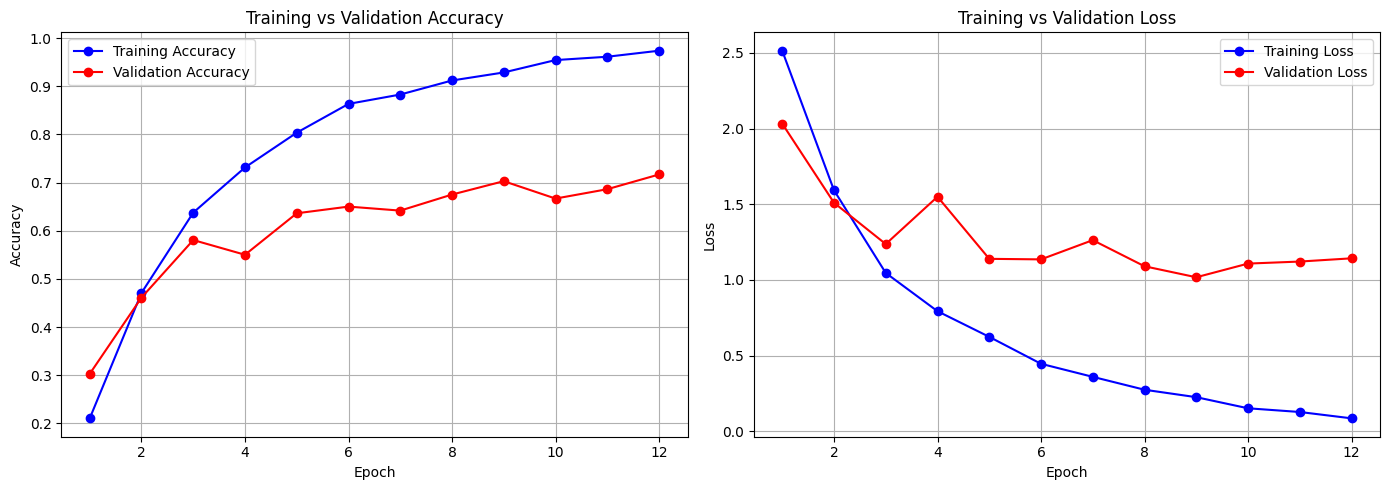

In [51]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, acc, 'bo-', label='Training Accuracy')
axes[0].plot(epochs_range, val_acc, 'ro-', label='Validation Accuracy')
axes[0].set_title('Training vs Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, loss, 'bo-', label='Training Loss')
axes[1].plot(epochs_range, val_loss, 'ro-', label='Validation Loss')
axes[1].set_title('Training vs Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Evaluate on the Validation Set

In [52]:
val_loss, val_accuracy = model.evaluate(validation_generator)
print(f'Validation Loss    : {val_loss:.4f}')
print(f'Validation Accuracy: {val_accuracy * 100:.2f}%')

90/90 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - accuracy: 0.9729 - loss: 0.1288
Validation Loss    : 0.1288
Validation Accuracy: 97.29%


## Interactive Prediction with Gradio

In [ ]:
# Install gradio if it's not already available in the environment
# !pip install -q gradio

In [56]:
import gradio as gr
from PIL import Image

def predict_celebrity(img):
    if img is None:
        return {}

    # Ensure we have a PIL image in RGB mode
    if not isinstance(img, Image.Image):
        img = Image.fromarray(img)
    img = img.convert('RGB').resize(img_size)

    # Preprocess exactly like the validation generator
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Run inference and return a {class_name: confidence} dict
    preds = model.predict(img_array, verbose=0)[0]
    return {idx_to_class[i]: float(preds[i]) for i in range(len(preds))}


demo = gr.Interface(
    fn=predict_celebrity,
    inputs=gr.Image(type='pil', label='Upload a celebrity face'),
    outputs=gr.Label(num_top_classes=5, label='Top-5 Predictions'),
    title='Celebrity Face Classifier (VGG16 Transfer Learning)',
    description=(
        'Upload an image of one of the 17 celebrities in the dataset '
        'and the model will predict who it is along with a confidence score.'
    ),
    flagging_mode='never'
)

demo.launch(debug=False)

* Running on local URL:  http://127.0.0.1:7862
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).


Could not create share link. Missing file: /root/.cache/huggingface/gradio/frpc/frpc_linux_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_linux_amd64
2. Rename the downloaded file to: frpc_linux_amd64_v0.3
3. Move the file to this location: /root/.cache/huggingface/gradio/frpc


In [69]:
from PIL import Image
import numpy as np

def predict_celebrity(image_path):
    # Create ID -> Class mapping
    idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

    # Load image
    img = Image.open(image_path).convert("RGB")
    img = img.resize((150, 150))

    # Preprocess
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    preds = model.predict(img_array, verbose=0)[0]

    # Top prediction
    pred_idx = np.argmax(preds)
    pred_class = idx_to_class[pred_idx]
    confidence = preds[pred_idx]

    print(f"Predicted Celebrity: {pred_class}")
    print(f"Class ID: {pred_idx}")
    print(f"Confidence: {confidence:.2%}")



In [70]:
image_path = r"/kaggle/input/datasets/mirajverisk/tom-image/tom.jpg"
predict_celebrity(image_path)


Predicted Celebrity: Tom Cruise
Class ID: 14
Confidence: 99.99%


## Save the Model

In [ ]:
# model.save('celebrity_face_classifier_vgg16.h5')
# print('Model saved to celebrity_face_classifier_vgg16.h5')